<a href="https://colab.research.google.com/github/IlinoisZiwei/2023Datathon/blob/main/Beta_Translator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Beta Translator: Video Pose Tracking with MediaPipe

This notebook builds the first computer vision component of the **Beta Translator** project.

### Current pipeline

`climbing video → pose tracking → skeleton visualization → pose coordinates → wall reference frame`

The notebook produces three main outputs:

1. `pose_output_h264.mp4` for visually checking the skeleton tracking.
2. `pose_coordinates.csv` for later hand and foot contact analysis.
3. `wall_reference.jpg` for manually annotating climbing holds.

At this stage, the goal is **not** to translate the beta yet. The goal is to obtain a reliable, structured representation of the climber's movement.


##### Copyright 2023 The MediaPipe Authors. All Rights Reserved.

In [ ]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

## 1. Environment Setup

Install MediaPipe and download the pretrained **Pose Landmarker Heavy** model.

The heavy model is used here because accuracy is more important than real time speed for the initial climbing video experiments.


In [ ]:
!pip install -q mediapipe


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 5.3 MB/s eta 0:00:00


In [ ]:
# Download the pretrained MediaPipe Pose Landmarker Heavy model.
!wget -O pose_landmarker.task -q https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task

print("Pose model downloaded.")


Pose model downloaded.


## 2. Imports and Visualization Helper

The helper function below draws the MediaPipe pose landmarks and skeleton connections on a video frame.

This visualization is primarily a **debugging tool**. Later stages of Beta Translator will use the numerical landmark coordinates rather than the rendered skeleton.


In [ ]:
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Video
from google.colab import files

from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles


def draw_landmarks_on_image(rgb_image, detection_result):
    # Draw detected pose landmarks and skeleton connections on an RGB frame.
    pose_landmarks_list = detection_result.pose_landmarks
    annotated_image = np.copy(rgb_image)

    pose_landmark_style = drawing_styles.get_default_pose_landmarks_style()
    pose_connection_style = drawing_utils.DrawingSpec(
        color=(0, 255, 0),
        thickness=2
    )

    for pose_landmarks in pose_landmarks_list:
        drawing_utils.draw_landmarks(
            image=annotated_image,
            landmark_list=pose_landmarks,
            connections=vision.PoseLandmarksConnections.POSE_LANDMARKS,
            landmark_drawing_spec=pose_landmark_style,
            connection_drawing_spec=pose_connection_style
        )

    return annotated_image


## 3. Upload the Climbing Video

Upload one short climbing video from a fixed camera.

For the first experiment, a video of roughly **10 to 20 seconds** is sufficient. The climber's full body should remain visible whenever possible.


In [ ]:
uploaded = files.upload()

VIDEO_FILE = next(iter(uploaded))
print("Uploaded video:", VIDEO_FILE)


Saving video.mp4 to video.mp4
Uploaded video: video.mp4


## 4. Run Pose Tracking and Create an Annotated Video

MediaPipe is configured in **VIDEO** mode. Each frame receives an increasing timestamp, which allows the model to use temporal tracking between frames.

The output of this section is `pose_output.mp4`, with the estimated skeleton drawn over the climber.


In [ ]:
# Create a MediaPipe Pose Landmarker configured for video.
base_options = python.BaseOptions(
    model_asset_path="pose_landmarker.task"
)

options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5,
    output_segmentation_masks=False
)

detector = vision.PoseLandmarker.create_from_options(options)

# Open the uploaded video.
cap = cv2.VideoCapture(VIDEO_FILE)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

if fps <= 0 or width <= 0 or height <= 0:
    raise ValueError("Could not read the uploaded video correctly.")

print(f"FPS: {fps:.2f}")
print(f"Video size: {width} x {height}")
print("Total frames:", frame_count)

# Create a video writer for the skeleton overlay.
output_path = "pose_output.mp4"
fourcc = cv2.VideoWriter_fourcc(*"mp4v")

writer = cv2.VideoWriter(
    output_path,
    fourcc,
    fps,
    (width, height)
)

frame_index = 0

while True:
    ret, frame_bgr = cap.read()

    if not ret:
        break

    # OpenCV reads BGR images, while MediaPipe expects RGB.
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=frame_rgb
    )

    # MediaPipe VIDEO mode requires increasing timestamps.
    timestamp_ms = int(frame_index * 1000 / fps)

    result = detector.detect_for_video(
        mp_image,
        timestamp_ms
    )

    # Draw the estimated skeleton for visual inspection.
    annotated_rgb = draw_landmarks_on_image(
        frame_rgb,
        result
    )

    annotated_bgr = cv2.cvtColor(
        annotated_rgb,
        cv2.COLOR_RGB2BGR
    )

    writer.write(annotated_bgr)
    frame_index += 1

cap.release()
writer.release()
detector.close()

print("Pose tracking finished.")
print("Saved:", output_path)


FPS: 30.00
Video size: 320 x 568
Total frames: 519
Pose tracking finished.
Saved: pose_output.mp4


## 5. Preview the Skeleton Tracking Result

OpenCV's default MP4 encoding may not display reliably inside every browser. The next cell converts the result to H.264 and then displays it.

When reviewing the video, focus on whether the **wrists, feet, hips, and shoulders** remain aligned with the climber during movement.


In [ ]:
# Convert to H.264 for more reliable playback in Colab/browser environments.
!ffmpeg -y -loglevel error -i pose_output.mp4 -vcodec libx264 pose_output_h264.mp4

Video(
    "pose_output_h264.mp4",
    embed=True
)


## 6. Export Pose Coordinates for Every Frame

The skeleton video is useful for visual inspection, but Beta Translator ultimately needs numerical data.

This section reruns pose tracking and stores selected landmarks for each frame. We save:

* normalized `x` and `y` coordinates;
* MediaPipe `z`;
* pixel `x` and `y` coordinates;
* landmark visibility.

The **pixel coordinates** will be especially useful in the next stage because manually annotated climbing holds will also be represented in image pixels.


In [ ]:
# Landmarks needed for climbing movement analysis.
important_landmarks = {
    "left_shoulder": 11,
    "right_shoulder": 12,
    "left_elbow": 13,
    "right_elbow": 14,
    "left_wrist": 15,
    "right_wrist": 16,
    "left_hip": 23,
    "right_hip": 24,
    "left_knee": 25,
    "right_knee": 26,
    "left_ankle": 27,
    "right_ankle": 28,
    "left_heel": 29,
    "right_heel": 30,
    "left_foot": 31,
    "right_foot": 32
}

# Create a fresh detector because the previous detector was closed.
base_options = python.BaseOptions(
    model_asset_path="pose_landmarker.task"
)

options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5,
    output_segmentation_masks=False
)

detector = vision.PoseLandmarker.create_from_options(options)

cap = cv2.VideoCapture(VIDEO_FILE)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

pose_data = []
frame_index = 0

while True:
    ret, frame_bgr = cap.read()

    if not ret:
        break

    frame_rgb = cv2.cvtColor(
        frame_bgr,
        cv2.COLOR_BGR2RGB
    )

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=frame_rgb
    )

    timestamp_ms = int(frame_index * 1000 / fps)

    result = detector.detect_for_video(
        mp_image,
        timestamp_ms
    )

    # Only create a row when MediaPipe detects a pose.
    if len(result.pose_landmarks) > 0:
        landmarks = result.pose_landmarks[0]

        row = {
            "frame": frame_index,
            "time_sec": frame_index / fps,
            "time_ms": timestamp_ms
        }

        for name, landmark_index in important_landmarks.items():
            landmark = landmarks[landmark_index]

            # Coordinates normalized relative to image width and height.
            row[f"{name}_x_norm"] = landmark.x
            row[f"{name}_y_norm"] = landmark.y

            # Relative depth estimate provided by MediaPipe.
            row[f"{name}_z"] = landmark.z

            # Pixel coordinates for later comparison with climbing holds.
            row[f"{name}_x_px"] = landmark.x * width
            row[f"{name}_y_px"] = landmark.y * height

            # Visibility helps identify potentially unreliable landmarks.
            row[f"{name}_visibility"] = landmark.visibility

        pose_data.append(row)

    frame_index += 1

cap.release()
detector.close()

pose_df = pd.DataFrame(pose_data)

pose_df.to_csv(
    "pose_coordinates.csv",
    index=False
)

print("Coordinate extraction finished.")
print("Frames with detected poses:", len(pose_df))
print("Saved: pose_coordinates.csv")

pose_df.head()


Coordinate extraction finished.
Frames with detected poses: 519
Saved: pose_coordinates.csv


,frame,time_sec,time_ms,left_shoulder_x_norm,left_shoulder_y_norm,left_shoulder_z,left_shoulder_x_px,left_shoulder_y_px,left_shoulder_visibility,right_shoulder_x_norm,...,left_foot_z,left_foot_x_px,left_foot_y_px,left_foot_visibility,right_foot_x_norm,right_foot_y_norm,right_foot_z,right_foot_x_px,right_foot_y_px,right_foot_visibility
0,0,0.000000,0,0.403712,0.455099,0.105058,129.187803,258.496241,0.999984,0.474864,...,-0.400451,124.185944,389.499436,0.998084,0.528540,0.648173,0.275721,169.132957,368.162487,0.952089
1,1,0.033333,33,0.407063,0.454803,0.080171,130.260105,258.328098,0.999983,0.483632,...,-0.383721,124.000845,388.433430,0.998024,0.528976,0.649332,0.093156,169.272270,368.820602,0.952218
2,2,0.066667,66,0.413161,0.454984,0.080705,132.211552,258.431154,0.999978,0.488753,...,-0.338706,122.412701,387.394610,0.996824,0.525654,0.653491,0.124336,168.209419,371.182967,0.941310
3,3,0.100000,100,0.417052,0.457977,0.083566,133.456697,260.130765,0.999971,0.493013,...,-0.310144,121.689882,384.145131,0.993398,0.523438,0.653871,0.161526,167.500229,371.398931,0.908056
4,4,0.133333,133,0.424829,0.458792,0.084824,135.945282,260.593840,0.999954,0.495389,...,-0.153681,124.879036,379.833743,0.980309,0.518145,0.653780,0.055945,165.806465,371.347166,0.867643


## 7. Extract a Reference Frame of the Climbing Wall

The next Beta Translator stage will require the locations of the climbing holds.

Choose a time when the climber blocks as few relevant holds as possible. The selected frame is saved as `wall_reference.jpg`.

Change `REFERENCE_TIME_SEC` and rerun the cell if another frame gives a clearer view of the route.


Saved frame 30 at 1.00 seconds.
Saved: wall_reference.jpg


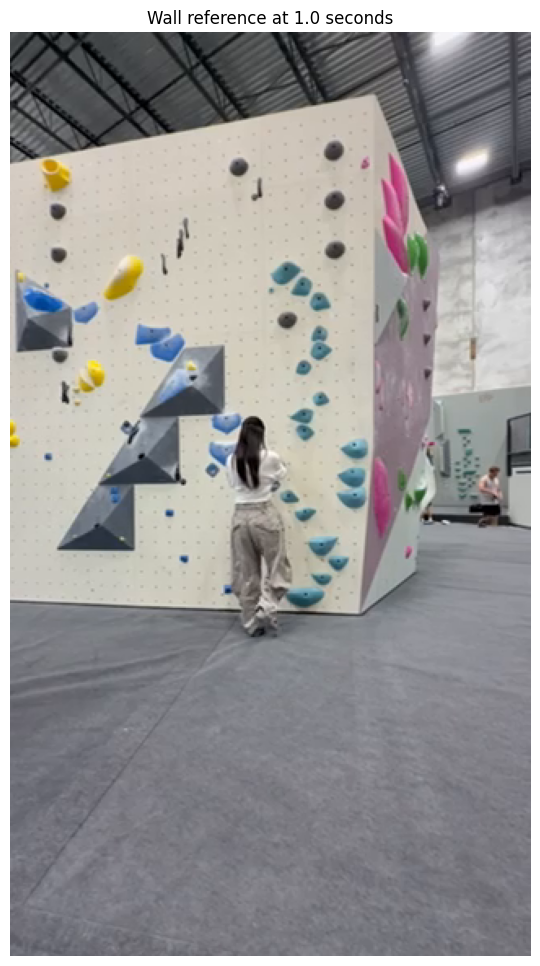

In [ ]:
# Select a clear moment from the video.
REFERENCE_TIME_SEC = 1.0

cap = cv2.VideoCapture(VIDEO_FILE)

fps = cap.get(cv2.CAP_PROP_FPS)
reference_frame_number = int(REFERENCE_TIME_SEC * fps)

cap.set(
    cv2.CAP_PROP_POS_FRAMES,
    reference_frame_number
)

ret, reference_frame = cap.read()
cap.release()

if not ret:
    raise ValueError(
        "Could not read the requested reference frame. "
        "Try a smaller REFERENCE_TIME_SEC value."
    )

cv2.imwrite(
    "wall_reference.jpg",
    reference_frame
)

print(
    f"Saved frame {reference_frame_number} "
    f"at {REFERENCE_TIME_SEC:.2f} seconds."
)
print("Saved: wall_reference.jpg")

# Display the selected wall frame.
reference_rgb = cv2.cvtColor(
    reference_frame,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(8, 12))
plt.imshow(reference_rgb)
plt.axis("off")
plt.title(
    f"Wall reference at {REFERENCE_TIME_SEC:.1f} seconds"
)
plt.show()


## 8. Outputs and Next Step

After running the notebook from top to bottom, you should have:

| Output | Purpose |
| --- | --- |
| `pose_output_h264.mp4` | Inspect skeleton tracking quality |
| `pose_coordinates.csv` | Numerical body landmark trajectories |
| `wall_reference.jpg` | Reference image for hold annotation |

### Next development step

Manually annotate the relevant climbing holds on `wall_reference.jpg`, assign each hold an ID, and save its pixel coordinates.

The subsequent pipeline will be:

`pose coordinates + hold coordinates → hand/foot contact detection → movement sequence → structured beta`


In [ ]:
!pwd
!ls

/content
pose_coordinates.csv  pose_output_h264.mp4  sample_data  wall_reference.jpg
pose_landmarker.task  pose_output.mp4	    video.mp4
